# Recuperacion de clave en SPN16: procedimiento paso a paso

Este notebook muestra la recuperacion estadistica de dos nibbles de la subclave final de SPN16.

El diferencial ya fue calculado previamente. Aqui se usa la trayectoria conocida

$$\mathtt{0B00}\longrightarrow\mathtt{0040}\longrightarrow\mathtt{0220}\longrightarrow\mathtt{0606}.$$

La diferencia en la entrada de la ultima capa de S-boxes es

$$\Delta U=\mathtt{0606}.$$

Por tanto, se atacan el segundo y el cuarto nibble del bloque, es decir, las posiciones 1 y 3 cuando se numeran desde cero.

## 1. Idea matematica

En la ultima ronda, el nibble $j$ del texto cifrado cumple

$$C_j=S(U_j)\oplus K_j.$$

Para un candidato $k$ de clave se deshace parcialmente la ultima ronda:

$$\widehat U_j(k)=S^{-1}(C_j\oplus k).$$

Para cada par de cifrados $(C,C')$ se comprueba si

$$\widehat U_j(k)\oplus\widehat U'_j(k)=\Delta U_j.$$

El conteo del candidato es

$$\operatorname{score}_j(k)=\sum_{i=1}^{N}\mathbf 1\left[\widehat U_{i,j}(k)\oplus\widehat U'_{i,j}(k)=\Delta U_j\right].$$

Como $\Delta U=\mathtt{0606}$, se tienen dos diferencias activas:

$$\Delta U_1=6,\qquad \Delta U_3=6.$$

Los dos nibbles pueden analizarse de manera independiente porque la ultima capa de S-boxes actua nibble a nibble.

In [12]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd


def add_repo_root_to_path():
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "cryptosystems").is_dir() and (path / "differential_cryptoanalysis").is_dir():
            if str(path) not in sys.path:
                sys.path.insert(0, str(path))
            return path
    raise RuntimeError("No se encontro la raiz del repositorio")


ROOT = add_repo_root_to_path()
from cryptosystems import spn16

pd.set_option("display.max_columns", None)
print(f"Repo root: {ROOT}")

Repo root: C:\Users\juanc\github\Differential-Cryptanalysis-


## 2. Parametros del experimento

La clave es conocida solamente para construir el oraculo y verificar el resultado al final. El algoritmo de conteo no usa el valor real de la clave.

Las posiciones se numeran de izquierda a derecha:

```text
posicion:       0    1    2    3
bloque 16-bit: [----][----][----][----]
Delta U:        0    6    0    6
```

Se emplean cuatro rondas. Las tres primeras terminan con permutacion y producen la diferencia `0606`; la cuarta es la ronda final que se invierte parcialmente.

In [13]:
ROUNDS = 4
MASTER_KEY_HEX = "00112233445566778899"

DELTA_P = 0x0B00
DELTA_U = 0x0606
N_PAIRS = 4000
SEED = 2026


def extract_nibble(block: int, position: int) -> int:
    shift = 4 * (3 - position)
    return (block >> shift) & 0xF


EXPECTED_DELTA_BY_POSITION = {
    position: extract_nibble(DELTA_U, position)
    for position in range(4)
    if extract_nibble(DELTA_U, position) != 0
}
TARGET_POSITIONS = list(EXPECTED_DELTA_BY_POSITION)

subkeys = spn16.expand_key_from_hex(MASTER_KEY_HEX, ROUNDS)


def oracle_encrypt(plaintext: int) -> int:
    return spn16.spn_encrypt_block(plaintext, subkeys, ROUNDS)


print(f"Rondas: {ROUNDS}")
print(f"Delta P: 0x{DELTA_P:04X}")
print(f"Delta U esperado: 0x{DELTA_U:04X}")
print(f"Posiciones atacadas: {TARGET_POSITIONS}")
print(f"Deltas por posicion: {EXPECTED_DELTA_BY_POSITION}")
print(f"Numero de pares: {N_PAIRS}")

Rondas: 4
Delta P: 0x0B00
Delta U esperado: 0x0606
Posiciones atacadas: [1, 3]
Deltas por posicion: {1: 6, 3: 6}
Numero de pares: 4000


## 3. S-box utilizada

El ataque necesita $S^{-1}$ para calcular la entrada estimada de la ultima S-box bajo cada hipotesis de clave.

In [14]:
sbox_df = pd.DataFrame({
    "x": [f"{x:X}" for x in range(16)],
    "S(x)": [f"{spn16.S_BOX[x]:X}" for x in range(16)],
    "S^-1(x)": [f"{spn16.S_BOX_INV[x]:X}" for x in range(16)],
})
sbox_df

,x,S(x),S^-1(x)
0,0,E,E
1,1,4,3
2,2,D,4
3,3,1,8
4,4,2,1
5,5,F,C
6,6,B,A
7,7,8,F
8,8,3,7
9,9,A,D


## 4. Generacion de pares elegidos

Se elige $P$ uniformemente y se construye

$$P'=P\oplus\Delta P.$$

Todos los pares satisfacen por construccion $P\oplus P'=\mathtt{0B00}$.

In [15]:
rng = random.Random(SEED)
plaintext_pairs = []

for _ in range(N_PAIRS):
    p = rng.randrange(0, 1 << 16)
    p_prime = p ^ DELTA_P
    plaintext_pairs.append((p, p_prime))

assert all((p ^ p_prime) == DELTA_P for p, p_prime in plaintext_pairs)

pd.DataFrame([
    {
        "P": f"0x{p:04X}",
        "P'": f"0x{p_prime:04X}",
        "P XOR P'": f"0x{p ^ p_prime:04X}",
    }
    for p, p_prime in plaintext_pairs[:8]
])

,P,P',P XOR P'
0,0x3CFD,0x37FD,0x0B00
1,0xA393,0xA893,0x0B00
2,0x348C,0x3F8C,0x0B00
3,0x7252,0x7952,0x0B00
4,0xD75A,0xDC5A,0x0B00
5,0xFB57,0xF057,0x0B00
6,0xE1D7,0xEAD7,0x0B00
7,0x7AD8,0x71D8,0x0B00


## 5. Consulta al oraculo

Cada texto del par se cifra con la misma clave secreta. Para el conteo solo se necesitan los nibbles 1 y 3 de cada cifrado.

In [16]:
ciphertext_pairs = [
    (oracle_encrypt(p), oracle_encrypt(p_prime))
    for p, p_prime in plaintext_pairs
]

ciphertext_rows = []
for c, c_prime in ciphertext_pairs[:8]:
    row = {
        "C": f"0x{c:04X}",
        "C'": f"0x{c_prime:04X}",
        "C XOR C'": f"0x{c ^ c_prime:04X}",
    }
    for position in TARGET_POSITIONS:
        row[f"C[{position}]"] = f"{extract_nibble(c, position):X}"
        row[f"C'[{position}]"] = f"{extract_nibble(c_prime, position):X}"
    ciphertext_rows.append(row)

pd.DataFrame(ciphertext_rows)

,C,C',C XOR C',C[1],C'[1],C[3],C'[3]
0,0xACCA,0x9283,0x3E49,C,2,A,3
1,0x2EDC,0xE479,0xCAA5,E,4,C,9
2,0xBE6C,0x881C,0x3670,E,8,C,C
3,0xC178,0x701F,0xB167,1,0,8,F
4,0x1EF3,0x35A5,0x2B56,E,5,3,5
5,0xCED3,0x986E,0x56BD,E,8,3,E
6,0xB7B2,0xBC47,0x0BF5,7,C,2,7
7,0x931D,0x0688,0x9595,3,6,D,8


## 6. Los 16 candidatos sobre un solo par

Cada nibble de clave tiene 16 candidatos. La tabla siguiente muestra la inversion parcial del primer par para ambas posiciones activas.

Un acierto aislado no identifica la clave. La informacion util aparece al acumular miles de pares.

In [17]:
first_c, first_c_prime = ciphertext_pairs[0]
single_pair_rows = []

for position, expected_delta in EXPECTED_DELTA_BY_POSITION.items():
    c_nibble = extract_nibble(first_c, position)
    c_prime_nibble = extract_nibble(first_c_prime, position)

    for key_guess in range(16):
        u_hat = spn16.S_BOX_INV[c_nibble ^ key_guess]
        u_hat_prime = spn16.S_BOX_INV[c_prime_nibble ^ key_guess]
        delta_u_hat = u_hat ^ u_hat_prime
        single_pair_rows.append({
            "posicion": position,
            "candidato k": f"{key_guess:X}",
            "U estimado": f"{u_hat:X}",
            "U' estimado": f"{u_hat_prime:X}",
            "Delta U estimado": f"{delta_u_hat:X}",
            "Delta U objetivo": f"{expected_delta:X}",
            "cumple": delta_u_hat == expected_delta,
        })

pd.DataFrame(single_pair_rows)

,posicion,candidato k,U estimado,U' estimado,Delta U estimado,Delta U objetivo,cumple
0,1,0,B,4,F,6,False
1,1,1,2,8,A,6,False
2,1,2,0,E,E,6,False
3,1,3,5,3,6,6,True
4,1,4,7,A,D,6,False
5,1,5,D,F,2,6,False
6,1,6,9,1,8,6,False
7,1,7,6,C,A,6,False
8,1,8,1,9,8,6,False
9,1,9,C,6,A,6,False


## 7. Conteo sobre todos los pares

Para cada posicion activa se prueban por separado los 16 candidatos. Un candidato recibe un punto cuando reproduce la diferencia esperada `6`.

In [18]:
def score_candidate(key_guess: int, position: int, expected_delta: int, pairs) -> int:
    score = 0
    for c, c_prime in pairs:
        c_nibble = extract_nibble(c, position)
        c_prime_nibble = extract_nibble(c_prime, position)

        u_hat = spn16.S_BOX_INV[c_nibble ^ key_guess]
        u_hat_prime = spn16.S_BOX_INV[c_prime_nibble ^ key_guess]

        if (u_hat ^ u_hat_prime) == expected_delta:
            score += 1
    return score


scores_by_position = {}
all_candidate_rows = []

for position, expected_delta in EXPECTED_DELTA_BY_POSITION.items():
    rows = []
    for key_guess in range(16):
        score = score_candidate(key_guess, position, expected_delta, ciphertext_pairs)
        row = {
            "position": position,
            "candidate_int": key_guess,
            "candidato": f"0x{key_guess:X}",
            "score": score,
            "proporcion": score / N_PAIRS,
        }
        rows.append(row)
        all_candidate_rows.append(row)

    position_df = pd.DataFrame(rows).sort_values(
        ["score", "candidate_int"], ascending=[False, True]
    ).reset_index(drop=True)
    position_df.index = position_df.index + 1
    position_df.index.name = "ranking"
    scores_by_position[position] = position_df

ranking_df = pd.concat(
    [df.assign(posicion=position) for position, df in scores_by_position.items()]
)[["posicion", "candidato", "score", "proporcion"]]

ranking_df

,posicion,candidato,score,proporcion
ranking,,,,
1,1,0x8,562,0.14050
2,1,0xD,411,0.10275
3,1,0x6,372,0.09300
4,1,0x5,333,0.08325
5,1,0x4,319,0.07975
6,1,0xB,318,0.07950
7,1,0x7,313,0.07825
8,1,0xA,310,0.07750
9,1,0xE,297,0.07425


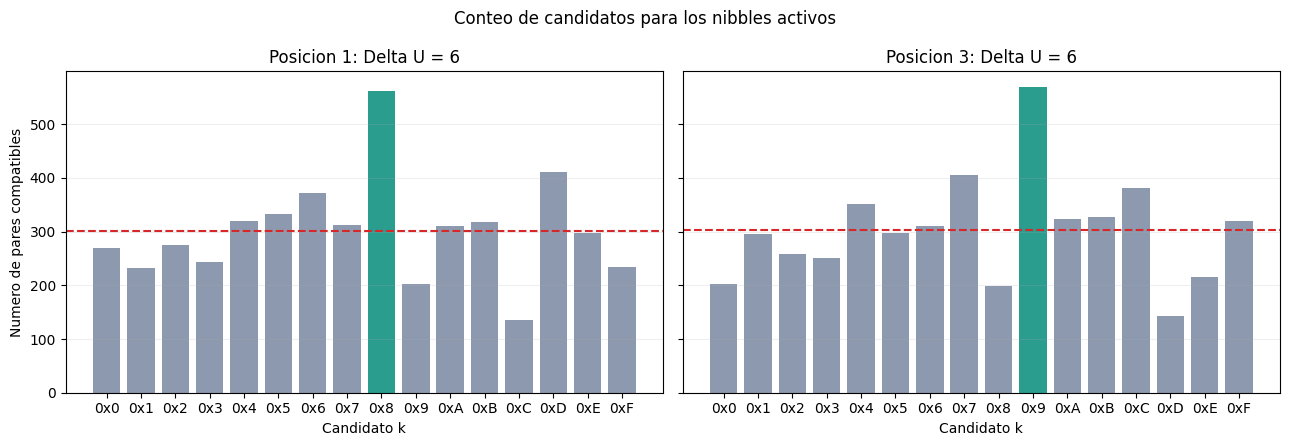

In [19]:
fig, axes = plt.subplots(1, len(TARGET_POSITIONS), figsize=(13, 4.5), sharey=True)

for ax, position in zip(axes, TARGET_POSITIONS):
    plot_df = scores_by_position[position].sort_values("candidate_int")
    best_guess = int(scores_by_position[position].iloc[0]["candidate_int"])
    colors = [
        "#2A9D8F" if value == best_guess else "#8D99AE"
        for value in plot_df["candidate_int"]
    ]
    ax.bar(plot_df["candidato"], plot_df["score"], color=colors)
    ax.axhline(plot_df["score"].mean(), color="#D62828", linestyle="--")
    ax.set_title(f"Posicion {position}: Delta U = 6")
    ax.set_xlabel("Candidato k")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Numero de pares compatibles")
fig.suptitle("Conteo de candidatos para los nibbles activos")
plt.tight_layout()
plt.show()

## 8. Resultado y verificacion

Se selecciona el candidato con mayor conteo en cada posicion. La clave real se consulta solamente en esta etapa para verificar el experimento.

Los nibbles no atacados se representan con `?`.

In [20]:
true_final_key = subkeys[-1]
best_guesses = {
    position: int(scores_by_position[position].iloc[0]["candidate_int"])
    for position in TARGET_POSITIONS
}
true_nibbles = {
    position: extract_nibble(true_final_key, position)
    for position in TARGET_POSITIONS
}

partial_key_nibbles = ["?", "?", "?", "?"]
for position, guess in best_guesses.items():
    partial_key_nibbles[position] = f"{guess:X}"
partial_key_text = "0x" + "".join(partial_key_nibbles)

result_rows = []
for position in TARGET_POSITIONS:
    df = scores_by_position[position]
    best_score = int(df.iloc[0]["score"])
    second_score = int(df.iloc[1]["score"])
    result_rows.append({
        "posicion": position,
        "Delta U": f"0x{EXPECTED_DELTA_BY_POSITION[position]:X}",
        "candidato recuperado": f"0x{best_guesses[position]:X}",
        "nibble real": f"0x{true_nibbles[position]:X}",
        "mejor score": best_score,
        "segundo score": second_score,
        "margen": best_score - second_score,
        "correcto": best_guesses[position] == true_nibbles[position],
    })

print(f"Subclave final real:     0x{true_final_key:04X}")
print(f"Subclave final parcial:  {partial_key_text}")
pd.DataFrame(result_rows)

Subclave final real:     0x8899
Subclave final parcial:  0x?8?9


,posicion,Delta U,candidato recuperado,nibble real,mejor score,segundo score,margen,correcto
0,1,0x6,0x8,0x8,562,411,151,True
1,3,0x6,0x9,0x9,570,405,165,True


## 9. Efecto del numero de pares

El ataque es estadistico. Con pocos pares, el candidato correcto puede no ocupar el primer lugar. Se estudia la evolucion de cada nibble usando prefijos del mismo conjunto de pares.

In [21]:
sample_sizes = [100, 250, 500, 1000, 2000, 4000]
stability_rows = []

for position, expected_delta in EXPECTED_DELTA_BY_POSITION.items():
    true_nibble = true_nibbles[position]

    for sample_size in sample_sizes:
        sample_pairs = ciphertext_pairs[:sample_size]
        sample_scores = {
            key_guess: score_candidate(key_guess, position, expected_delta, sample_pairs)
            for key_guess in range(16)
        }
        ranking = sorted(sample_scores, key=lambda key_guess: sample_scores[key_guess], reverse=True)
        best_wrong_score = max(
            score for key_guess, score in sample_scores.items() if key_guess != true_nibble
        )

        stability_rows.append({
            "posicion": position,
            "pares": sample_size,
            "mejor candidato": f"0x{ranking[0]:X}",
            "score clave real": sample_scores[true_nibble],
            "mejor score incorrecto": best_wrong_score,
            "margen clave real": sample_scores[true_nibble] - best_wrong_score,
            "rango clave real": ranking.index(true_nibble) + 1,
        })

stability_df = pd.DataFrame(stability_rows)
stability_df

,posicion,pares,mejor candidato,score clave real,mejor score incorrecto,margen clave real,rango clave real
0,1,100,0xD,14,18,-4,2
1,1,250,0xD,31,34,-3,2
2,1,500,0x8,71,67,4,1
3,1,1000,0x8,137,123,14,1
4,1,2000,0x8,296,232,64,1
5,1,4000,0x8,562,411,151,1
6,3,100,0x4,8,13,-5,8
7,3,250,0x7,23,30,-7,3
8,3,500,0x9,65,51,14,1
9,3,1000,0x9,137,104,33,1


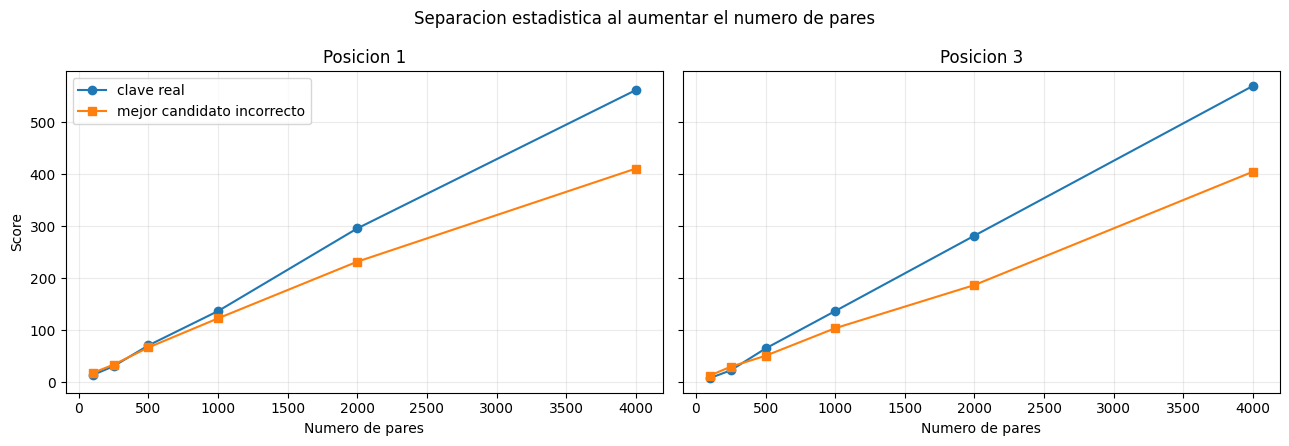

In [22]:
fig, axes = plt.subplots(1, len(TARGET_POSITIONS), figsize=(13, 4.5), sharey=True)

for ax, position in zip(axes, TARGET_POSITIONS):
    position_df = stability_df[stability_df["posicion"] == position]
    ax.plot(position_df["pares"], position_df["score clave real"], marker="o", label="clave real")
    ax.plot(
        position_df["pares"],
        position_df["mejor score incorrecto"],
        marker="s",
        label="mejor candidato incorrecto",
    )
    ax.set_title(f"Posicion {position}")
    ax.set_xlabel("Numero de pares")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Score")
axes[0].legend()
fig.suptitle("Separacion estadistica al aumentar el numero de pares")
plt.tight_layout()
plt.show()

## 10. Lectura de los resultados

Los resultados muestran lo siguiente:

1. La diferencia `0606` activa exactamente las posiciones 1 y 3 antes de la ultima capa de S-boxes.
2. Cada nibble se recupera con un ranking independiente de 16 candidatos.
3. En este experimento se recupera la subclave parcial `0x?8?9` de la subclave real `0x8899`.
4. Los nibbles correctos presentan un conteo mayor que el resto cuando se emplean suficientes pares.
5. La diferencia entre el primer y segundo score permite medir la claridad del resultado.

Para dos posiciones activas, el costo principal es aproximadamente

$$2\cdot 2^4\cdot N=32N$$

pruebas candidato-par. El costo crece linealmente con el numero de pares y con el numero de nibbles atacados.

## 11. Texto base para una tesis

> Se utilizo una caracteristica diferencial previamente calculada con diferencia de entrada `0B00` y diferencia `0606` en la entrada de la ultima capa de sustitucion. Esta diferencia activa el segundo y el cuarto nibble del estado. Para cada posicion se probaron de manera independiente los dieciseis valores posibles del nibble de la subclave final. Bajo cada hipotesis se elimino el XOR de clave del texto cifrado y se aplico la S-box inversa. El candidato recibio un punto cuando la diferencia obtenida coincidio con el valor esperado `6`. Los candidatos se ordenaron por su numero de coincidencias y se selecciono el de mayor conteo en cada posicion. Con 4000 pares, el procedimiento recupero los nibbles `8` y `9`, produciendo la subclave parcial `?8?9`.

Al documentar el experimento conviene reportar:

- la trayectoria diferencial completa;
- la diferencia en la entrada de la ultima S-box;
- las posiciones activas;
- el numero de pares y la semilla;
- el ranking de los 16 candidatos para cada posicion;
- el margen entre los dos primeros candidatos;
- la estabilidad del resultado al aumentar el numero de pares.

## 12. Limitaciones

- La clave real se conoce en este experimento controlado para validar el resultado.
- El ataque depende de la probabilidad y calidad de la caracteristica diferencial calculada previamente.
- Solo se recuperan los nibbles correspondientes a posiciones activas en `0606`.
- Los nibbles primero y tercero requieren otros diferenciales o experimentos adicionales.
- Obtener la clave maestra exige recuperar suficientes bits de subclave y analizar el calendario de claves.